In [74]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep
from copy import deepcopy
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [75]:
runs_F222 = [7733, 8712]
runs_F223 = [8713, 9188]

runs_F231 = [10555, 11470]
runs_F232 = [11470, 11703]

runs_F241 = [14399, 15026]
runs_tungsten = [15030, 15594]
runs_F242 = [15652, 15820]
runs_caloNu = [15821, 16924]
runs_F243 = [16928, 17230]

runs_2022 = [8025, 9188]
runs_2023 = [10604, 11703]

runs_2024_preCaloNu = [14399, 15821]
runs_2024_CaloNu = [15821, 16924]
runs_2024_afterCaloNu = [16928, 17230]

In [76]:
def parse_grl_csv(file_path):
    grl_df = pd.read_csv(file_path)
    return grl_df

grl_2022_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2022_physics.csv")
grl_2023_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2023_physics.csv")
grl_2024_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2024_physics.csv")
grl_df = pd.concat([grl_2022_df, grl_2023_df, grl_2024_df], ignore_index=True)

In [77]:
def get_files_for_runs(run_range, data_files):
    selected_files = []
    for file in data_files:
        # Extract the run number from the filename
        run_number = int(os.path.basename(file).split('.')[0])
        if run_range[0] <= run_number <= run_range[1]:
            selected_files.append(file)
    return selected_files

In [78]:
data_files = glob.glob("AnalysisZipFramework/submission/analysis_output-lateTracks/*.root")

files_F222 = get_files_for_runs(runs_F222, data_files)
files_F223 = get_files_for_runs(runs_F223, data_files)
files_F231 = get_files_for_runs(runs_F231, data_files)
files_F232 = get_files_for_runs(runs_F232, data_files)
files_F241 = get_files_for_runs(runs_F241, data_files)
files_tungsten = get_files_for_runs(runs_tungsten, data_files)
files_F242 = get_files_for_runs(runs_F242, data_files)
files_caloNu = get_files_for_runs(runs_caloNu, data_files)
files_F243 = get_files_for_runs(runs_F243, data_files)


In [79]:
def check_files(files):

    new_files = []
    for file in tqdm(files):
        try:
            data = uproot.open(f"{file}:nt")
            new_files.append(file)
        except Exception as e:
            print(f"Error opening file {file}: {e}")
            continue
    return new_files

In [80]:
files_F222 = check_files(files_F222)
files_F223 = check_files(files_F223)
files_F231 = check_files(files_F231)
files_F232 = check_files(files_F232)
files_F241 = check_files(files_F241)
files_tungsten = check_files(files_tungsten)
files_F242 = check_files(files_F242)
files_caloNu = check_files(files_caloNu)
files_F243 = check_files(files_F243)

100%|██████████| 22/22 [00:05<00:00,  4.25it/s]


In [81]:
print(f"Files for F222: {len(files_F222)}")
print(f"Files for F223: {len(files_F223)}")
print(f"Files for F231: {len(files_F231)}")
print(f"Files for F232: {len(files_F232)}")
print(f"Files for F241: {len(files_F241)}")
print(f"Files for tungsten: {len(files_tungsten)}")
print(f"Files for F242: {len(files_F242)}")
print(f"Files for caloNu: {len(files_caloNu)}")
print(f"Files for F243: {len(files_F243)}")

Files for F222: 89
Files for F223: 74
Files for F231: 53
Files for F232: 20
Files for F241: 41
Files for tungsten: 33
Files for F242: 27
Files for caloNu: 123
Files for F243: 22


In [82]:
colours = ["lightcoral", "firebrick", "olive", "olivedrab", "teal", "lightblue", "steelblue", "magenta", "purple"]

hists_dict = {
    "F222": {"files": files_F222, "runs": runs_F222, "colour": colours[0]},
    "F223": {"files": files_F223, "runs": runs_F223, "colour": colours[1]},
    "F231": {"files": files_F231, "runs": runs_F231, "colour": colours[2]},
    "F232": {"files": files_F232, "runs": runs_F232, "colour": colours[3]},
    "F241": {"files": files_F241, "runs": runs_F241, "colour": colours[4]},
    "tungsten": {"files": files_tungsten, "runs": runs_tungsten, "colour": colours[5]},
    "F242": {"files": files_F242, "runs": runs_F242, "colour": colours[6]},
    "caloNu": {"files": files_caloNu, "runs": runs_caloNu, "colour": colours[7]},
    "F243": {"files": files_F243, "runs": runs_F243, "colour": colours[8]},
}

In [83]:
status_set = set()
# Status set: {np.int32(0), np.int32(1), np.int32(513), np.int32(512), np.int32(4), np.int32(36), np.int32(32), np.int32(16), np.int32(48)}


for period, info in tqdm(hists_dict.items()):

    data = uproot.concatenate([f"{f}:nt" for f in info["files"]], library="ak", filter_name=["LeadTrack_pz0", "LeadTrack_qop", "*_status"])

    pz = data["LeadTrack_pz0"]
    qop = data["LeadTrack_qop"]

    bins = [100, 300, 600, 1000]
    h_pz = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())

    bins = [-1/100e3, -1/300e3, -1/600e3, -1/1000e3, 1/1000e3, 1/600e3, 1/300e3, 1/100e3]
    h_qop = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())

    h_pz.fill(pz)
    h_qop.fill(qop)

    hists_dict[period]["h_pz"] = h_pz
    hists_dict[period]["h_qop"] = h_qop

    for var in data.fields:
        if not var.endswith("_status"): continue

        var_arr = data[var]

        status_set.update(set(var_arr))

        # Create a new array where values equal to 4 or 516 (512+4) are set to 1, and all other values are set to 0
        var_arr_saturated = [1 if x == 4 or x == (512+4) else 0 for x in var_arr]
        # var_arr_digi_corr = [x for x in var_arr if x < 512 else x - 512]  # Correcting values greater than or equal to 512
    
        print(var, var_arr, var_arr_saturated)

        bins = [0, 1]
        h_var_saturated = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
        h_var_saturated.fill(var_arr_saturated)
        hists_dict[period][f"h_{var}_saturated"] = h_var_saturated

        bins = [0, 1, 2, 4, 16, 32, 36, 48, 512, 513]
        h_var = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
        h_var.fill(var_arr)
        hists_dict[period][f"h_{var}"] = h_var

print(f"Status set: {status_set}")

 11%|█         | 1/9 [00:17<02:16, 17.00s/it]

Calo0_status [1, 1, 1, 1, 1, 1, 1] [0, 0, 0, 0, 0, 0, 0]
Calo1_status [1, 1, 1, 0, 1, 0, 1] [0, 0, 0, 0, 0, 0, 0]
Calo2_status [0, 0, 1, 1, 0, 1, 1] [0, 0, 0, 0, 0, 0, 0]
Calo3_status [1, 0, 0, 1, 1, 0, 1] [0, 0, 0, 0, 0, 0, 0]
Preshower0_status [0, 0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 0, 0]
Preshower1_status [0, 0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 0, 0]
Timing0_status [1, 0, 1, 0, 1, 0, 0] [0, 0, 0, 0, 0, 0, 0]
Timing1_status [1, 0, 1, 0, 1, 0, 0] [0, 0, 0, 0, 0, 0, 0]
Timing2_status [0, 0, 0, 1, 0, 0, 0] [0, 0, 0, 0, 0, 0, 0]
Timing3_status [0, 0, 0, 1, 0, 0, 0] [0, 0, 0, 0, 0, 0, 0]
Veto10_status [0, 0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 0, 0]
Veto20_status [0, 0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 0, 0]
Veto21_status [0, 0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 0, 0]
VetoNu0_status [0, 0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 0, 0]
VetoNu1_status [0, 0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 0, 0]


 22%|██▏       | 2/9 [00:30<01:45, 15.06s/it]

Calo0_status [1, 1, 1] [0, 0, 0]
Calo1_status [1, 1, 1] [0, 0, 0]
Calo2_status [1, 1, 1] [0, 0, 0]
Calo3_status [1, 1, 1] [0, 0, 0]
Preshower0_status [0, 0, 0] [0, 0, 0]
Preshower1_status [0, 0, 0] [0, 0, 0]
Timing0_status [0, 16, 0] [0, 0, 0]
Timing1_status [0, 1, 0] [0, 0, 0]
Timing2_status [0, 0, 0] [0, 0, 0]
Timing3_status [0, 0, 0] [0, 0, 0]
Veto10_status [0, 0, 0] [0, 0, 0]
Veto20_status [0, 0, 0] [0, 0, 0]
Veto21_status [0, 0, 0] [0, 0, 0]
VetoNu0_status [0, 0, 0] [0, 0, 0]
VetoNu1_status [0, 0, 0] [0, 0, 0]


 33%|███▎      | 3/9 [00:41<01:18, 13.01s/it]

...

CaloHi0_status [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 513, 1] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
CaloHi1_status [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 513, 1] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
CaloHi2_status [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 513, 1] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
CaloHi3_status [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 513, 1] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
CaloLo0_status [0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
CaloLo1_status [0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
CaloLo2_status [1, 1, 0, 1, 0, 1, 1, 1, 16, 1, 0, 1, 1] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
CaloLo3_status [1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Preshower0_status [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Preshower1_status [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Timing0_status [0, 0, 1, 0, 0, 0, 1

 89%|████████▉ | 8/9 [01:37<00:14, 14.68s/it]

CaloHi0_status [513, 1, 1, 1, 1, 0, 1, 512, 513, 1, 1, ..., 513, 1, 1, 1, 513, 1, 513, 1, 1, 1] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
CaloHi1_status [513, 1, 1, 1, 1, 1, 1, 513, 513, 1, 1, ..., 513, 1, 1, 1, 513, 1, 513, 1, 1, 1] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
CaloHi2_status [513, 1, 1, 1, 1, 1, 1, 513, 513, 0, 1, ..., 513, 1, 1, 1, 513, 1, 513, 1, 1, 1] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
CaloHi3_status [513, 1, 1, 1, 1, 1, 1, 513, 513, 1, 1, ..., 513, 1, 1, 1, 513, 1, 513, 1, 1, 1] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

100%|██████████| 9/9 [01:42<00:00, 11.44s/it]

CaloHi0_status [513, 1, 1, 1, 1, 1] [0, 0, 0, 0, 0, 0]
CaloHi1_status [513, 1, 1, 1, 1, 1] [0, 0, 0, 0, 0, 0]
CaloHi2_status [513, 1, 1, 1, 1, 1] [0, 0, 0, 0, 0, 0]
CaloHi3_status [513, 1, 1, 1, 1, 1] [0, 0, 0, 0, 0, 0]
CaloLo0_status [0, 0, 1, 1, 1, 1] [0, 0, 0, 0, 0, 0]
CaloLo1_status [1, 1, 1, 1, 1, 1] [0, 0, 0, 0, 0, 0]
CaloLo2_status [1, 1, 0, 0, 0, 1] [0, 0, 0, 0, 0, 0]
CaloLo3_status [1, 1, 0, 0, 1, 0] [0, 0, 0, 0, 0, 0]
Preshower0_status [0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 0]
Preshower1_status [0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 0]
Timing0_status [0, 0, 0, 1, 0, 0] [0, 0, 0, 0, 0, 0]
Timing1_status [0, 0, 16, 1, 0, 0] [0, 0, 0, 0, 0, 0]
Timing2_status [0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 0]
Timing3_status [0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 0]
Veto10_status [0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 0]
Veto11_status [0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 0]
Veto20_status [0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 0]
Veto21_status [0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 0]
VetoNu0_status [0, 0, 0, 0, 0, 0] [

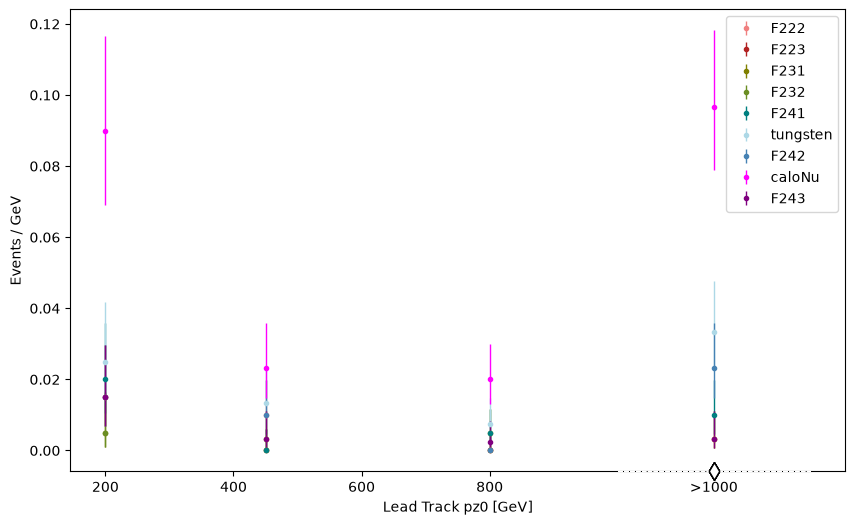

In [84]:
fig, ax = plt.subplots(figsize=(10, 6))

h_caloNu = deepcopy(hists_dict["caloNu"]["h_pz"])

for period, info in hists_dict.items():
    h_pz = deepcopy(info["h_pz"])

    mplhep.histplot(h_pz, ax=ax, label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', binwnorm=1)

ax.set_ylabel("Events / GeV")
ax.set_xlabel("Lead Track pz0 [GeV]")
ax.legend()

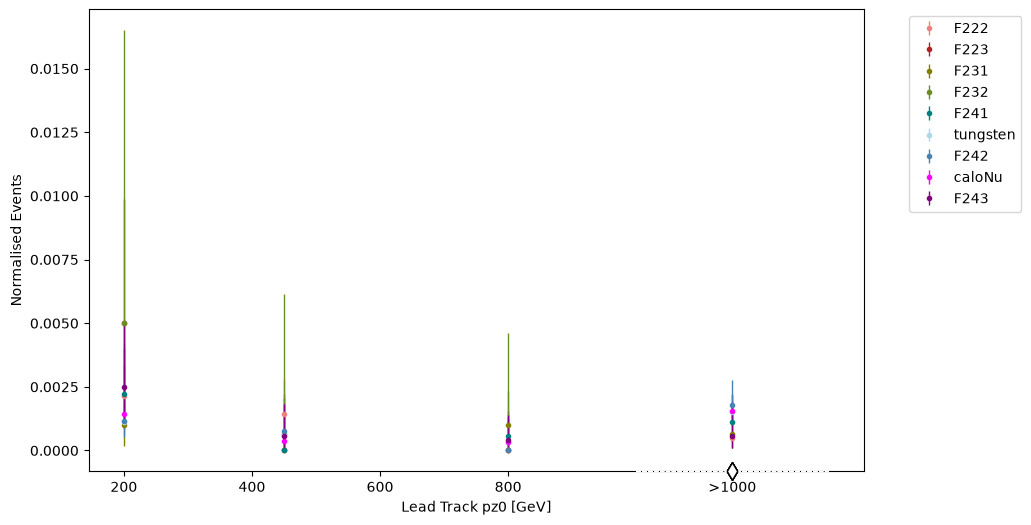

In [85]:
fig, ax = plt.subplots(figsize=(10, 6))

h_caloNu = deepcopy(hists_dict["caloNu"]["h_pz"])

for period, info in hists_dict.items():
    h_pz = deepcopy(info["h_pz"])

    mplhep.histplot(h_pz, ax=ax, label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', density=True)

ax.set_ylabel("Normalised Events")
ax.set_xlabel("Lead Track pz0 [GeV]")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [86]:
# fig, ax = plt.subplots(figsize=(10, 6), nrows=2)

# h_caloNu = deepcopy(hists_dict["caloNu"]["h_pz"])

# for period, info in hists_dict.items():

#     if period == "F222" or period == "F223" or period == "F231" or period == "F232":
#         continue



#     h_pz = deepcopy(info["h_pz"])

#     mplhep.histplot(h_pz, ax=ax[0], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', binwnorm=1)


#     if period != "caloNu":

#         h_calonu_norm = deepcopy(h_caloNu) / h_caloNu.sum()
#         h_pz_norm = deepcopy(h_pz) / h_pz.sum()

#         h_ratio = h_pz_norm / h_calonu_norm

#         mplhep.histplot(h_ratio, ax=ax[1], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show')

# ax[1].axhline(1, color="black", linestyle="--", linewidth=1)

# ax[0].set_ylabel("Events / GeV")
# ax[0].set_xlabel("Lead Track pz0 [GeV]")
# ax[0].legend()

In [87]:
def ratio_with_errors(h_num, h_den, flow=True):
    """Ratio of two normalised histograms with propagated uncertainties,
    optionally including under/overflow bins."""
    num_vals = h_num.values(flow=flow)
    den_vals = h_den.values(flow=flow)

    num_sum = h_num.sum(flow=flow)
    den_sum = h_den.sum(flow=flow)

    num_norm = num_vals / num_sum
    den_norm = den_vals / den_sum

    try:
        num_var = h_num.variances(flow=flow)
        den_var = h_den.variances(flow=flow)
    except RuntimeError:
        num_var = num_vals
        den_var = den_vals

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(den_norm != 0, num_norm / den_norm, np.nan)
        rel_err = np.sqrt(
            np.where(num_vals != 0, num_var / num_vals**2, 0)
            + np.where(den_vals != 0, den_var / den_vals**2, 0)
        )
        ratio_err = ratio * rel_err

    return ratio, ratio_err


def bin_centers_with_flow(h, flow=True):
    """Bin centers including under/overflow, placed one bin-width outside
    the first/last edge."""
    edges = h.axes[0].edges
    centers = h.axes[0].centers

    if not flow:
        return centers

    underflow_width = edges[1] - edges[0]
    overflow_width = edges[-1] - edges[-2]

    underflow_center = edges[0] - underflow_width / 2
    overflow_center = edges[-1] + overflow_width / 2

    return np.concatenate([[underflow_center], centers, [overflow_center]])

Text(0, 0.5, 'Normalised Events')

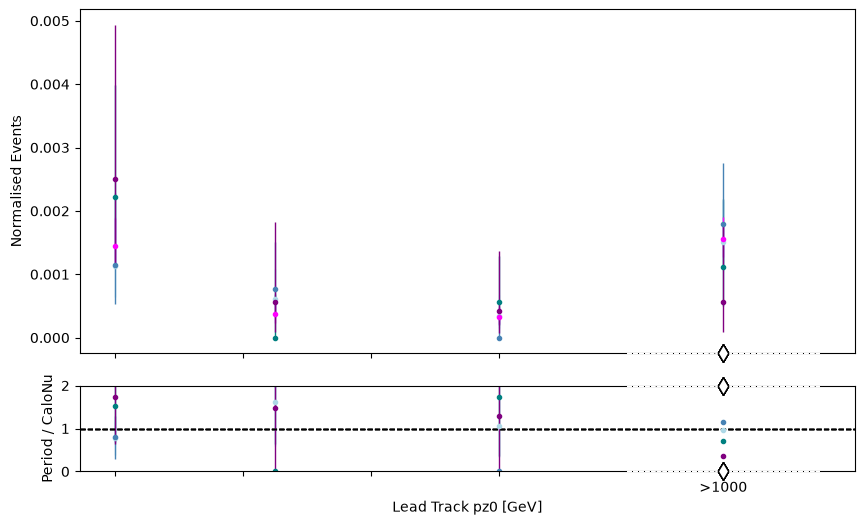

In [88]:
fig, ax = mplhep.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)

h_caloNu = deepcopy(hists_dict["caloNu"]["h_pz"])

for period, info in hists_dict.items():

    if period == "F222" or period == "F223" or period == "F231" or period == "F232":
        continue

    h_pz = deepcopy(info["h_pz"])

    density = True  # Set to True for normalised histograms, False for raw counts

    mplhep.histplot(h_pz, ax=ax[0], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', density=density)


    if period != "caloNu":

        n1 = (1.0 / h_pz.sum(flow=True).value)
        n2 = (1.0 / h_caloNu.sum(flow=True).value)

        h_pz_norm = h_pz * n1
        h_caloNu_norm = h_caloNu * n2

        mplhep.comp.comparison(h_pz_norm, h_caloNu_norm, ax=ax[1], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', density=False, comparison='ratio')

        # bin_centers = bin_centers_with_flow(h_caloNu, flow=True)

        # ratio, ratio_err = ratio_with_errors(h_pz, h_caloNu, flow=True)

        # ax[1].errorbar(bin_centers, ratio, yerr=ratio_err,
        #                 color=info["colour"], linewidth=2,
        #                 fmt='o', markersize=4)

ax[1].axhline(1, color="black", linestyle="--", linewidth=1)
ax[1].set_ylabel("Period / CaloNu")
ax[1].set_xlabel("Lead Track pz0 [GeV]")

ax[0].set_ylabel("Normalised Events")

Period: F222, h_qop sum: 7.0
Period: F223, h_qop sum: 3.0
Period: F231, h_qop sum: 5.0
Period: F232, h_qop sum: 1.0
Period: F241, h_qop sum: 9.0
Period: tungsten, h_qop sum: 22.0
Period: F242, h_qop sum: 13.0
Period: caloNu, h_qop sum: 62.0
Period: F243, h_qop sum: 6.0


<Axes: xlabel='Lead Track q/p [GeV]', ylabel='Period / CaloNu'>

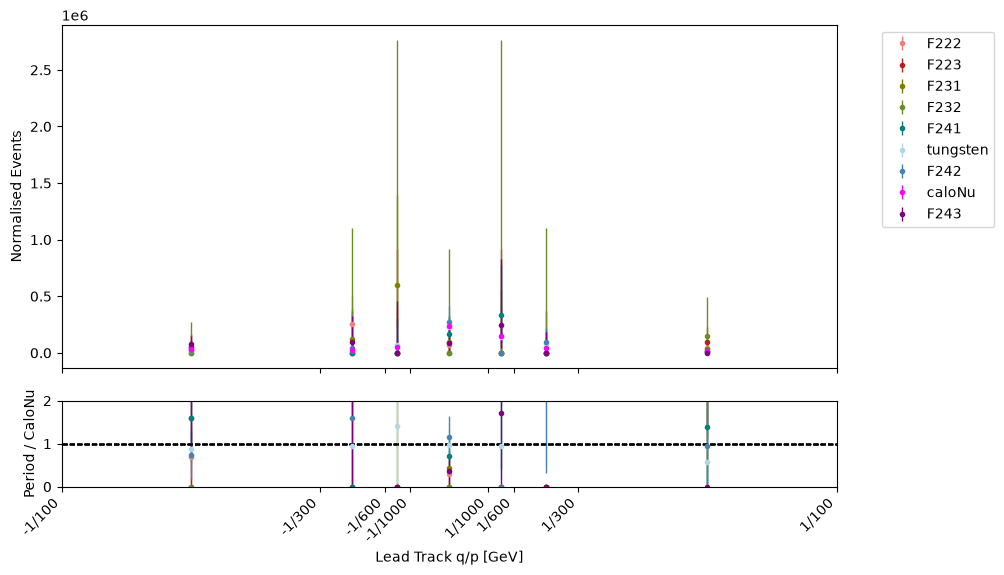

In [89]:
fig, ax = mplhep.subplots(nrows=2, ncols=1, figsize=(10, 6))

h_caloNu = deepcopy(hists_dict["caloNu"]["h_qop"])

for period, info in hists_dict.items():

    # if period == "F222" or period == "F223" or period == "F231" or period == "F232":
    #     continue

    h_qop = deepcopy(info["h_qop"])

    print(f"Period: {period}, h_qop sum: {h_qop.sum(flow=True).value}")

    density = True  # Set to True for normalised histograms, False for raw counts

    mplhep.histplot(h_qop, ax=ax[0], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', density=True)
    # mplhep.histplot(h_qop, ax=ax[0], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', binwnorm=1)


    if period != "caloNu":

        n1 = (1.0 / h_qop.sum(flow=True).value)
        n2 = (1.0 / h_caloNu.sum(flow=True).value)

        h_qop_norm = h_qop * n1
        h_caloNu_norm = h_caloNu * n2

        mplhep.comp.comparison(h_qop_norm, h_caloNu_norm, ax=ax[1], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', density=False, comparison='ratio')

        # bin_centers = bin_centers_with_flow(h_caloNu, flow=True)

        # ratio, ratio_err = ratio_with_errors(h_pz, h_caloNu, flow=True)

        # ax[1].errorbar(bin_centers, ratio, yerr=ratio_err,
        #                 color=info["colour"], linewidth=2,
        #                 fmt='o', markersize=4)

ax[1].axhline(1, color="black", linestyle="--", linewidth=1)
ax[1].set_ylabel("Period / CaloNu")
ax[1].set_xlabel("Lead Track q/p [GeV]")



tick_positions = [-1/100e3, -1/300e3, -1/600e3, -1/1000e3, 1/1000e3, 1/600e3, 1/300e3, 1/100e3]
# tick_positions = [-1, -2, -3, -4, 4, 3, 2, 1]  # Adjusted tick positions for better visibility
tick_labels = ["-1/100", "-1/300", "-1/600", "-1/1000", "1/1000", "1/600", "1/300", "1/100"]
tick_labels_dummy = ["" for _ in tick_labels]  # Create a list of empty strings for dummy labels

ax[1].set_xticks(tick_positions)
ax[1].set_xticklabels(tick_labels)
ax[1].set_xticklabels(tick_labels, rotation=45, ha='right')

ax[0].set_xticks(tick_positions)
ax[0].set_xticklabels(tick_labels)
ax[0].set_xticklabels(tick_labels_dummy, rotation=45, ha='right')


ax[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax[0].set_ylabel("Normalised Events")
mplhep.mpl_magic(soft_fail=True)


Period: F222, h_qop sum: 7.0
Period: F223, h_qop sum: 3.0
Period: F231, h_qop sum: 5.0
Period: F232, h_qop sum: 1.0
Period: F241, h_qop sum: 9.0
Period: tungsten, h_qop sum: 22.0
Period: F242, h_qop sum: 13.0
Period: caloNu, h_qop sum: 62.0
Period: F243, h_qop sum: 6.0


<Axes: xlabel='Lead Track q/p [1/GeV]', ylabel='Period / CaloNu'>

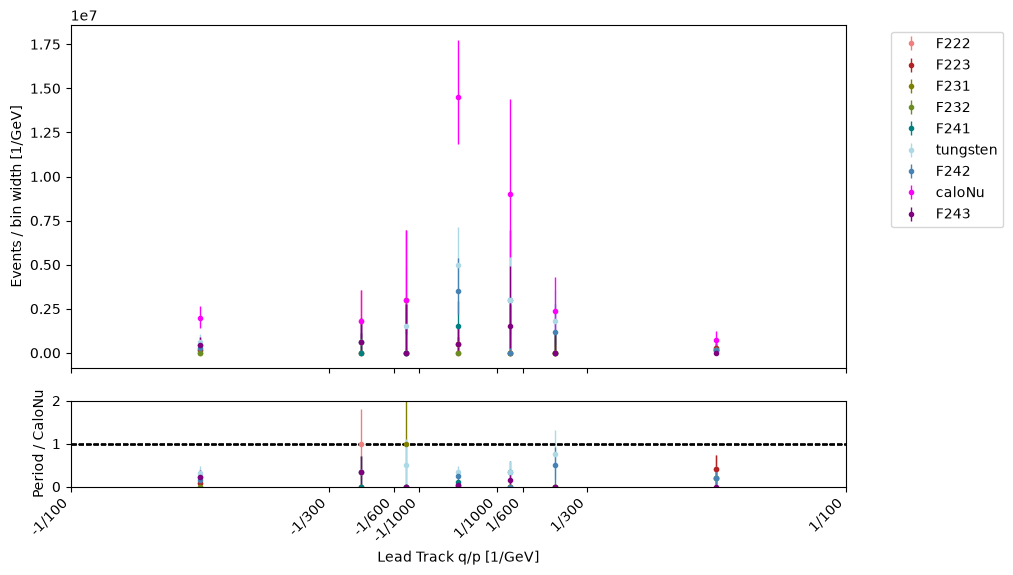

In [90]:
fig, ax = mplhep.subplots(nrows=2, ncols=1, figsize=(10, 6))

h_caloNu = deepcopy(hists_dict["caloNu"]["h_qop"])

for period, info in hists_dict.items():

    # if period == "F222" or period == "F223" or period == "F231" or period == "F232":
    #     continue

    h_qop = deepcopy(info["h_qop"])

    print(f"Period: {period}, h_qop sum: {h_qop.sum(flow=True).value}")

    density = False  # Set to True for normalised histograms, False for raw counts

    # mplhep.histplot(h_qop, ax=ax[0], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', density=density)
    mplhep.histplot(h_qop, ax=ax[0], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', binwnorm=1)


    if period != "caloNu":

        # n1 = (1.0 / h_qop.sum(flow=True).value)
        # n2 = (1.0 / h_caloNu.sum(flow=True).value)

        # h_pz_norm = h_qop * n1
        # h_caloNu_norm = h_caloNu * n2

        mplhep.comp.comparison(h_qop, h_caloNu, ax=ax[1], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', density=False, comparison='ratio')

        # bin_centers = bin_centers_with_flow(h_caloNu, flow=True)

        # ratio, ratio_err = ratio_with_errors(h_pz, h_caloNu, flow=True)

        # ax[1].errorbar(bin_centers, ratio, yerr=ratio_err,
        #                 color=info["colour"], linewidth=2,
        #                 fmt='o', markersize=4)

ax[1].axhline(1, color="black", linestyle="--", linewidth=1)
ax[1].set_ylabel("Period / CaloNu")
ax[1].set_xlabel("Lead Track q/p [1/GeV]")



tick_positions = [-1/100e3, -1/300e3, -1/600e3, -1/1000e3, 1/1000e3, 1/600e3, 1/300e3, 1/100e3]
# tick_positions = [-1, -2, -3, -4, 4, 3, 2, 1]  # Adjusted tick positions for better visibility
tick_labels = ["-1/100", "-1/300", "-1/600", "-1/1000", "1/1000", "1/600", "1/300", "1/100"]
tick_labels_dummy = ["" for _ in tick_labels]  # Create a list of empty strings for dummy labels

ax[1].set_xticks(tick_positions)
ax[1].set_xticklabels(tick_labels)
ax[1].set_xticklabels(tick_labels, rotation=45, ha='right')

ax[0].set_xticks(tick_positions)
ax[0].set_xticklabels(tick_labels)
ax[0].set_xticklabels(tick_labels_dummy, rotation=45, ha='right')


ax[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax[0].set_ylabel("Events / bin width [1/GeV]")
mplhep.mpl_magic(soft_fail=True)


In [91]:
hists_dict

{'F222': {'files': ['AnalysisZipFramework/submission/analysis_output-lateTracks/8174.root',
   'AnalysisZipFramework/submission/analysis_output-lateTracks/7989.root',
   'AnalysisZipFramework/submission/analysis_output-lateTracks/7835.root',
   'AnalysisZipFramework/submission/analysis_output-lateTracks/8039.root',
   'AnalysisZipFramework/submission/analysis_output-lateTracks/8025.root',
   'AnalysisZipFramework/submission/analysis_output-lateTracks/8297.root',
   'AnalysisZipFramework/submission/analysis_output-lateTracks/8112.root',
   'AnalysisZipFramework/submission/analysis_output-lateTracks/8333.root',
   'AnalysisZipFramework/submission/analysis_output-lateTracks/8266.root',
   'AnalysisZipFramework/submission/analysis_output-lateTracks/8155.root',
   'AnalysisZipFramework/submission/analysis_output-lateTracks/8137.root',
   'AnalysisZipFramework/submission/analysis_output-lateTracks/8327.root',
   'AnalysisZipFramework/submission/analysis_output-lateTracks/8243.root',
   'Anal

Error accessing Calo0_status for period F241: no field 'Calo0_status' in record with 13 fields
Error accessing Calo0_status for period tungsten: no field 'Calo0_status' in record with 13 fields
Error accessing Calo0_status for period F242: no field 'Calo0_status' in record with 13 fields
Error accessing Calo0_status for period caloNu: no field 'Calo0_status' in record with 13 fields
Error accessing Calo0_status for period F243: no field 'Calo0_status' in record with 13 fields
Saturation value 4 not found in Calo0_status for plotting.
Saturation value 36 not found in Calo0_status for plotting.
Saturation value 516 not found in Calo0_status for plotting.


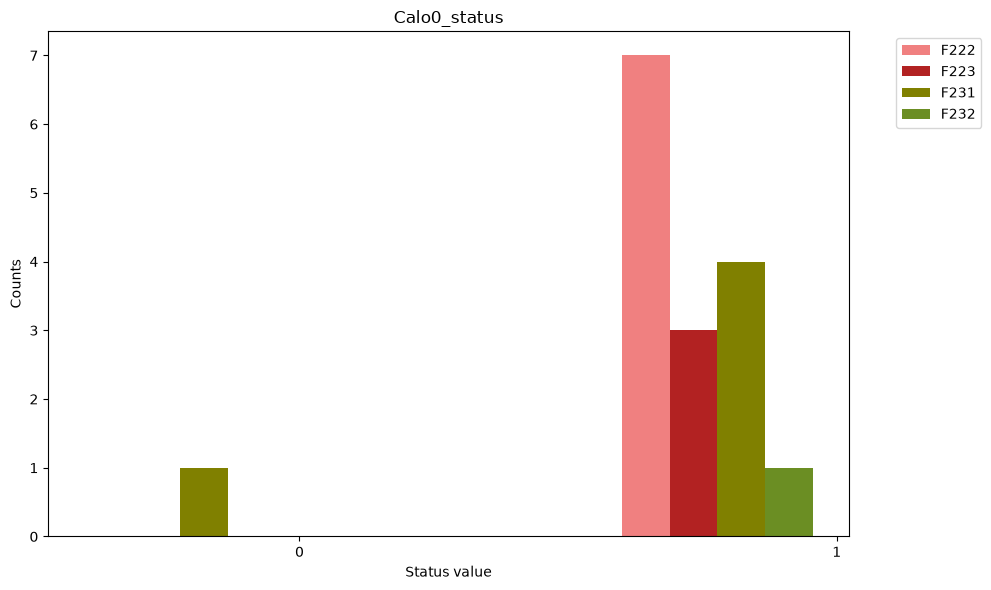

Error accessing Calo1_status for period F241: no field 'Calo1_status' in record with 13 fields
Error accessing Calo1_status for period tungsten: no field 'Calo1_status' in record with 13 fields
Error accessing Calo1_status for period F242: no field 'Calo1_status' in record with 13 fields
Error accessing Calo1_status for period caloNu: no field 'Calo1_status' in record with 13 fields
Error accessing Calo1_status for period F243: no field 'Calo1_status' in record with 13 fields
Saturation value 4 not found in Calo1_status for plotting.
Saturation value 36 not found in Calo1_status for plotting.
Saturation value 516 not found in Calo1_status for plotting.


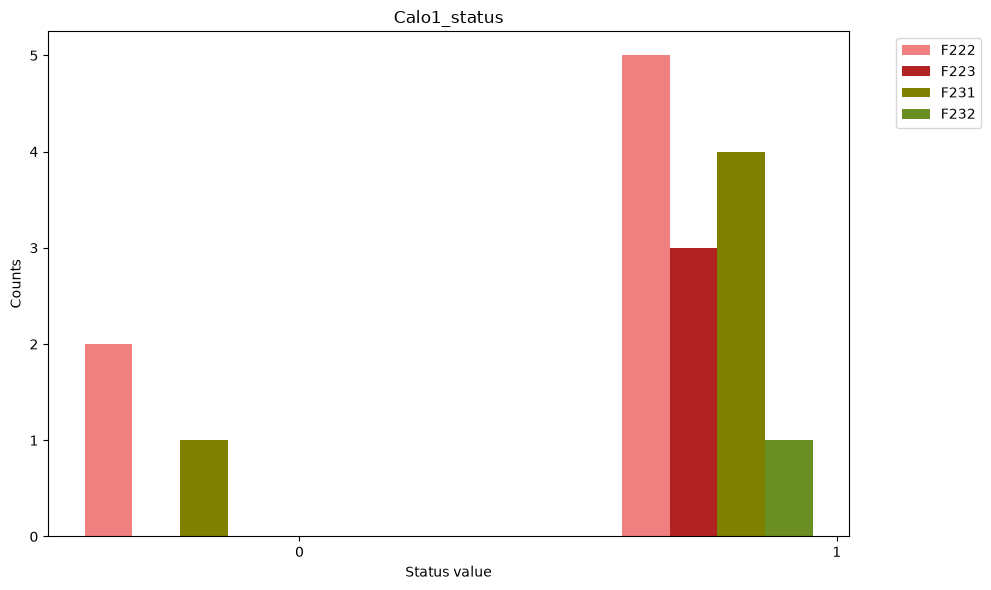

Error accessing Calo2_status for period F241: no field 'Calo2_status' in record with 13 fields
Error accessing Calo2_status for period tungsten: no field 'Calo2_status' in record with 13 fields
Error accessing Calo2_status for period F242: no field 'Calo2_status' in record with 13 fields
Error accessing Calo2_status for period caloNu: no field 'Calo2_status' in record with 13 fields
Error accessing Calo2_status for period F243: no field 'Calo2_status' in record with 13 fields
Saturation value 4 not found in Calo2_status for plotting.
Saturation value 36 not found in Calo2_status for plotting.
Saturation value 516 not found in Calo2_status for plotting.


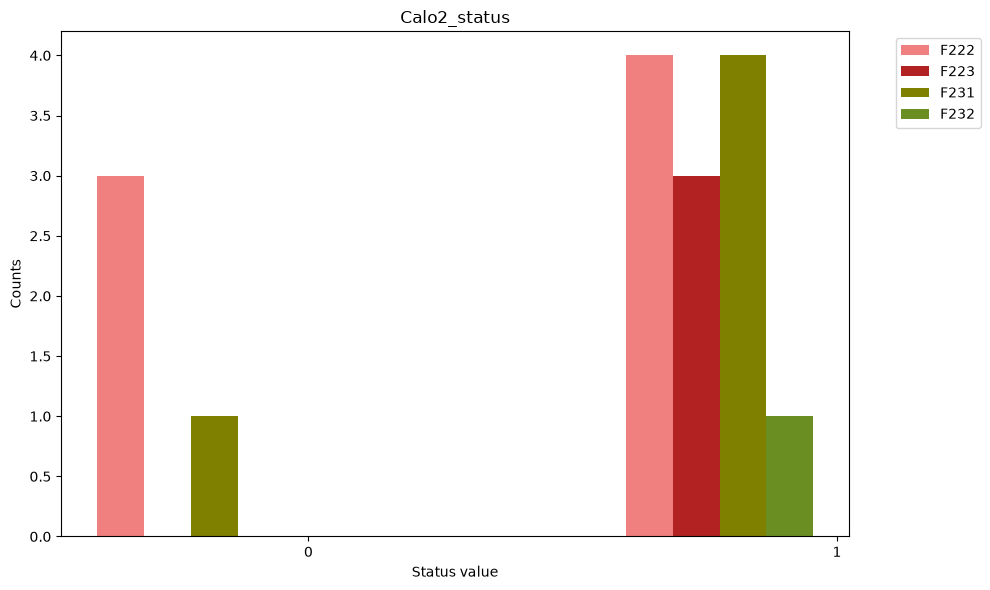

Error accessing Calo3_status for period F241: no field 'Calo3_status' in record with 13 fields
Error accessing Calo3_status for period tungsten: no field 'Calo3_status' in record with 13 fields
Error accessing Calo3_status for period F242: no field 'Calo3_status' in record with 13 fields
Error accessing Calo3_status for period caloNu: no field 'Calo3_status' in record with 13 fields
Error accessing Calo3_status for period F243: no field 'Calo3_status' in record with 13 fields
Saturation value 4 not found in Calo3_status for plotting.
Saturation value 36 not found in Calo3_status for plotting.
Saturation value 516 not found in Calo3_status for plotting.


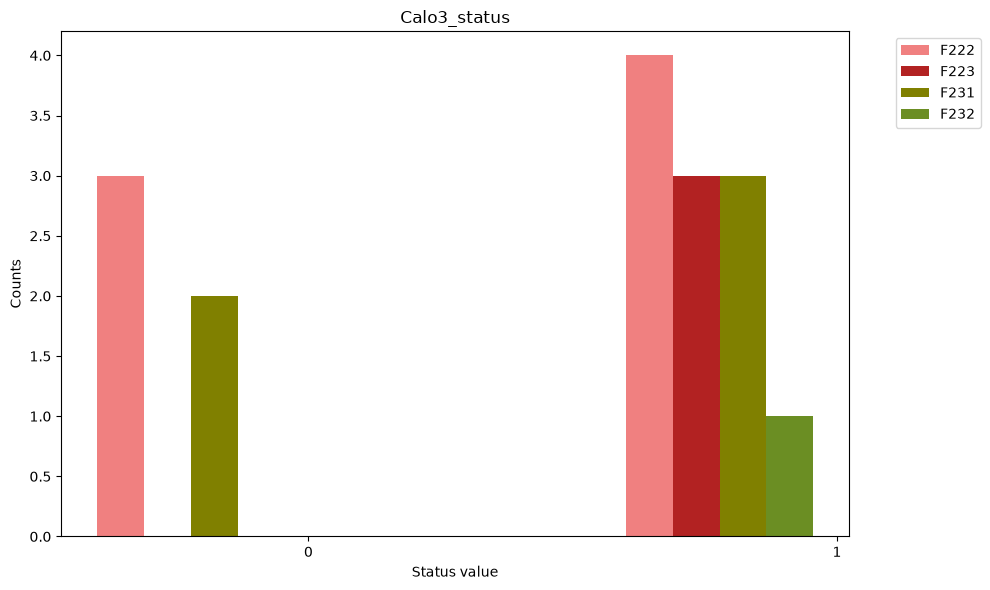

Saturation value 4 not found in Preshower0_status for plotting.
Saturation value 36 not found in Preshower0_status for plotting.
Saturation value 516 not found in Preshower0_status for plotting.


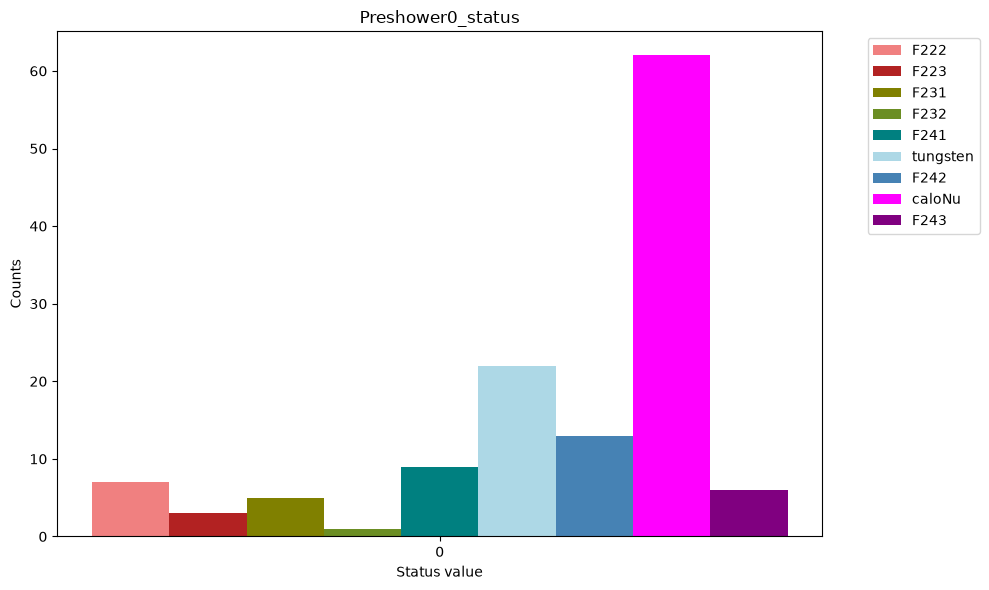

Saturation value 4 not found in Preshower1_status for plotting.
Saturation value 36 not found in Preshower1_status for plotting.
Saturation value 516 not found in Preshower1_status for plotting.


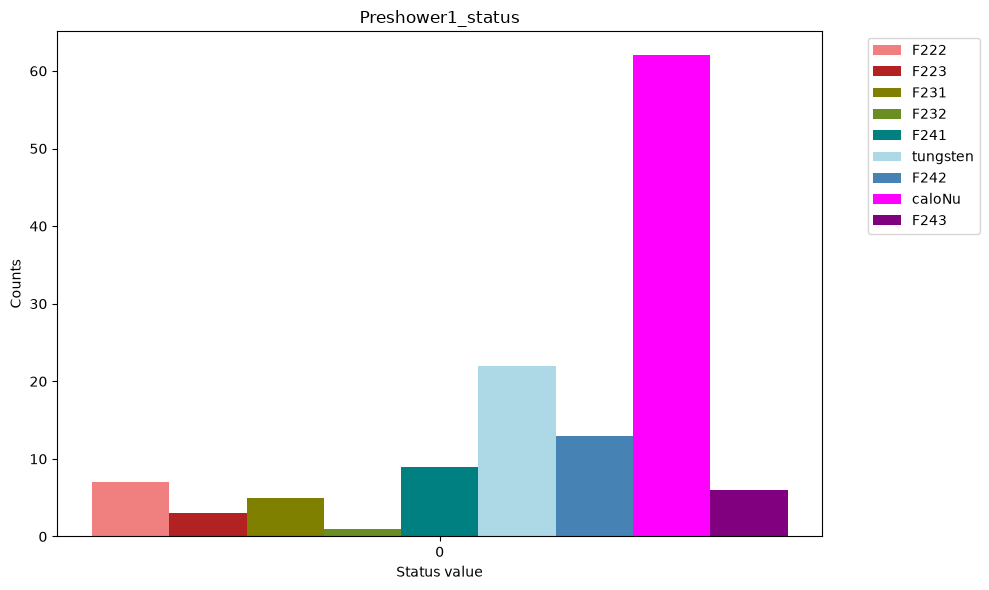

Saturation value 4 not found in Timing0_status for plotting.
Saturation value 36 not found in Timing0_status for plotting.
Saturation value 516 not found in Timing0_status for plotting.


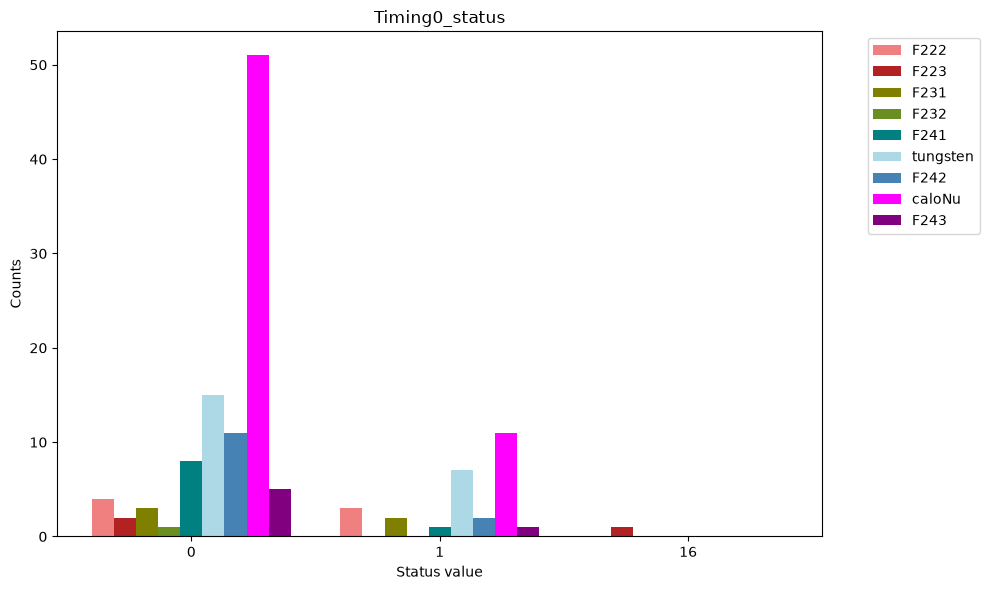

Saturation value 4 not found in Timing1_status for plotting.
Saturation value 36 not found in Timing1_status for plotting.
Saturation value 516 not found in Timing1_status for plotting.


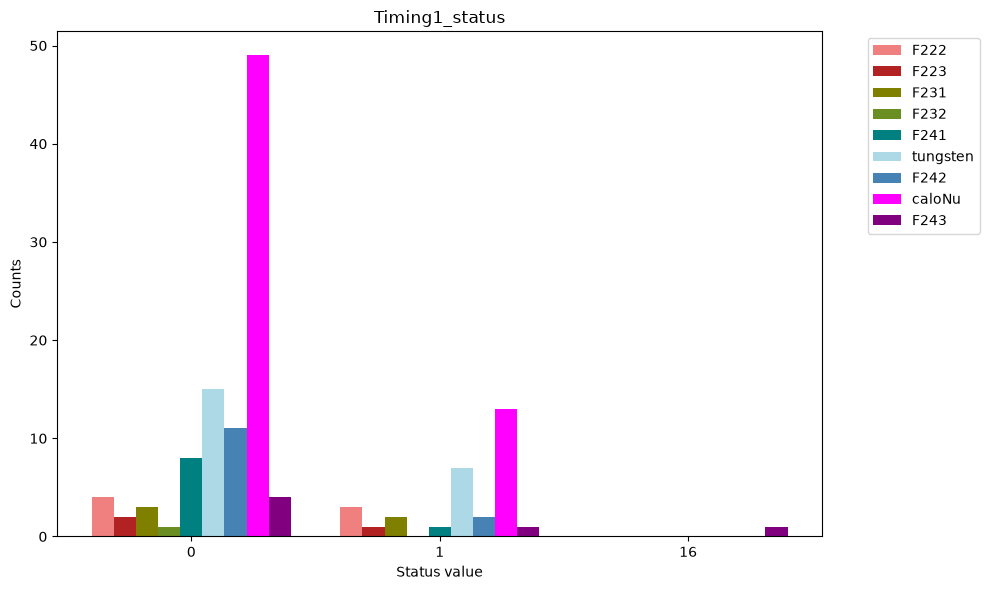

Saturation value 36 not found in Timing2_status for plotting.
Saturation value 516 not found in Timing2_status for plotting.


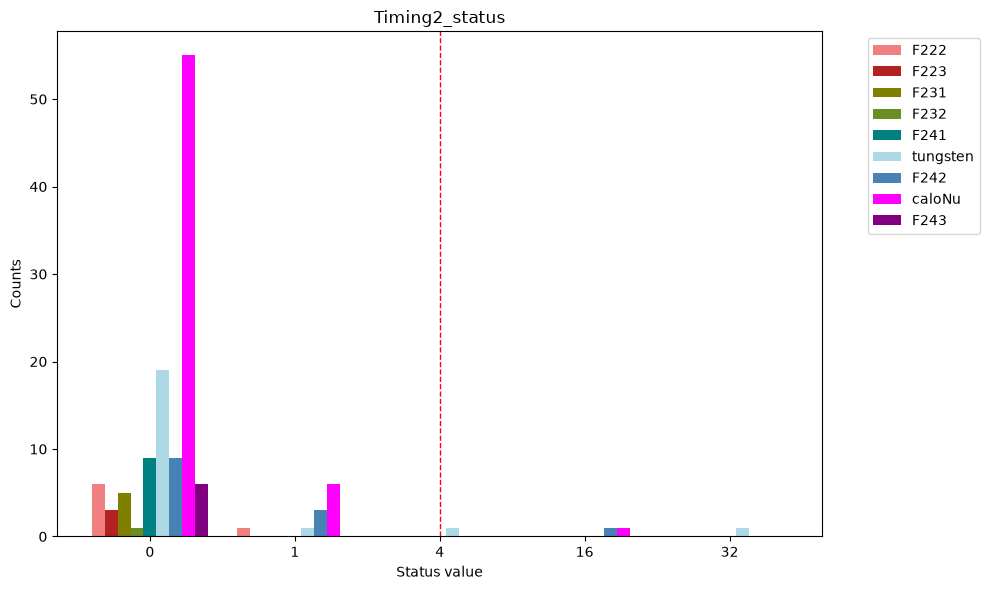

Saturation value 36 not found in Timing3_status for plotting.
Saturation value 516 not found in Timing3_status for plotting.


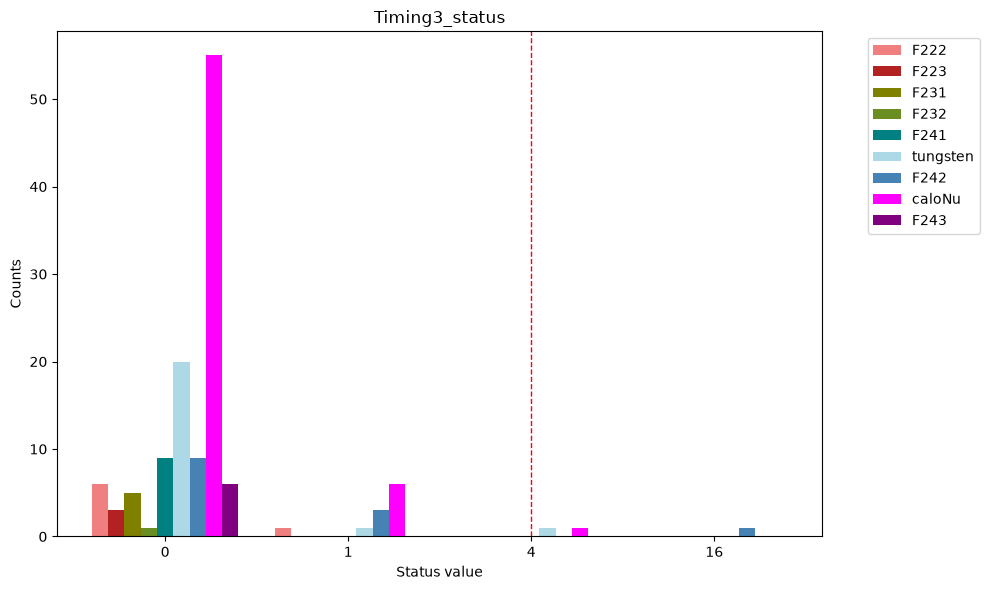

Saturation value 516 not found in Veto10_status for plotting.


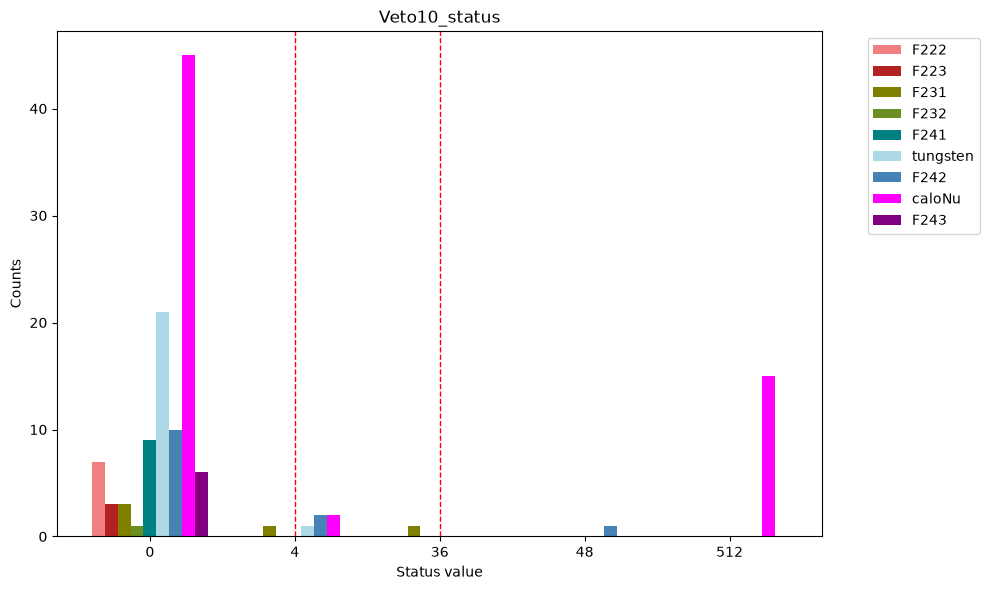

Saturation value 36 not found in Veto20_status for plotting.
Saturation value 516 not found in Veto20_status for plotting.


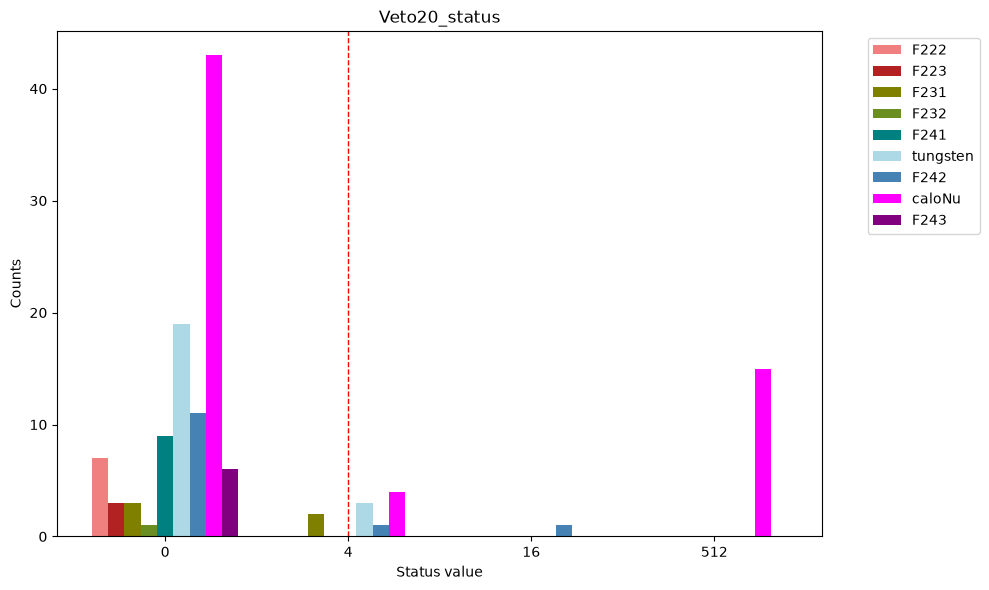

Saturation value 36 not found in Veto21_status for plotting.
Saturation value 516 not found in Veto21_status for plotting.


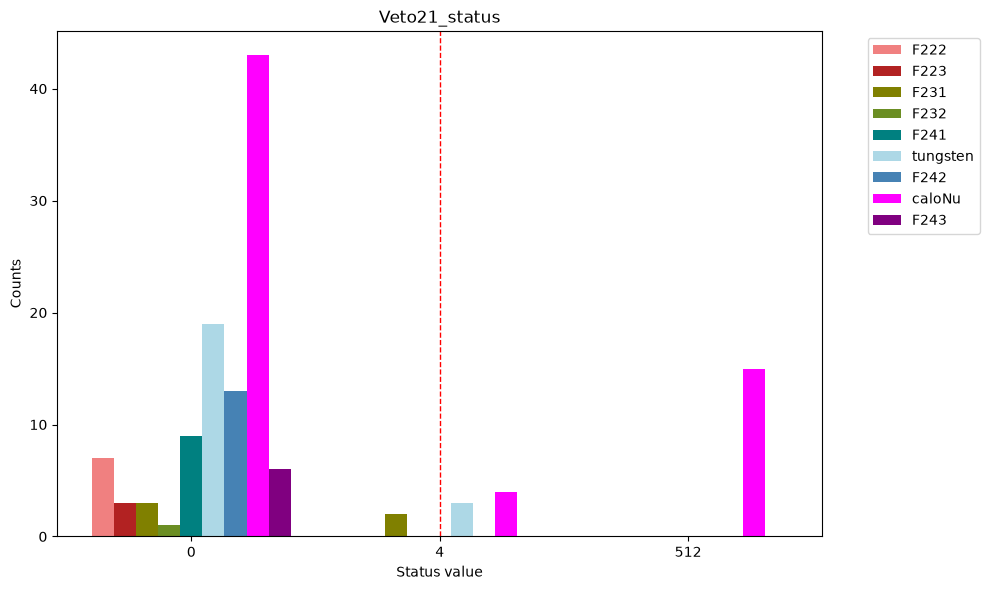

Saturation value 4 not found in VetoNu0_status for plotting.
Saturation value 36 not found in VetoNu0_status for plotting.
Saturation value 516 not found in VetoNu0_status for plotting.


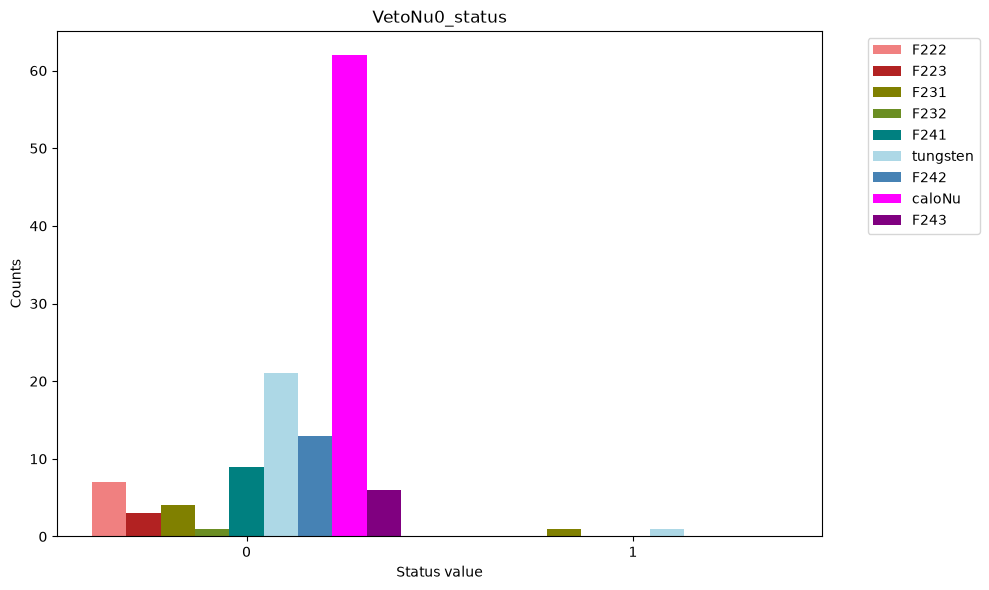

Saturation value 4 not found in VetoNu1_status for plotting.
Saturation value 36 not found in VetoNu1_status for plotting.
Saturation value 516 not found in VetoNu1_status for plotting.


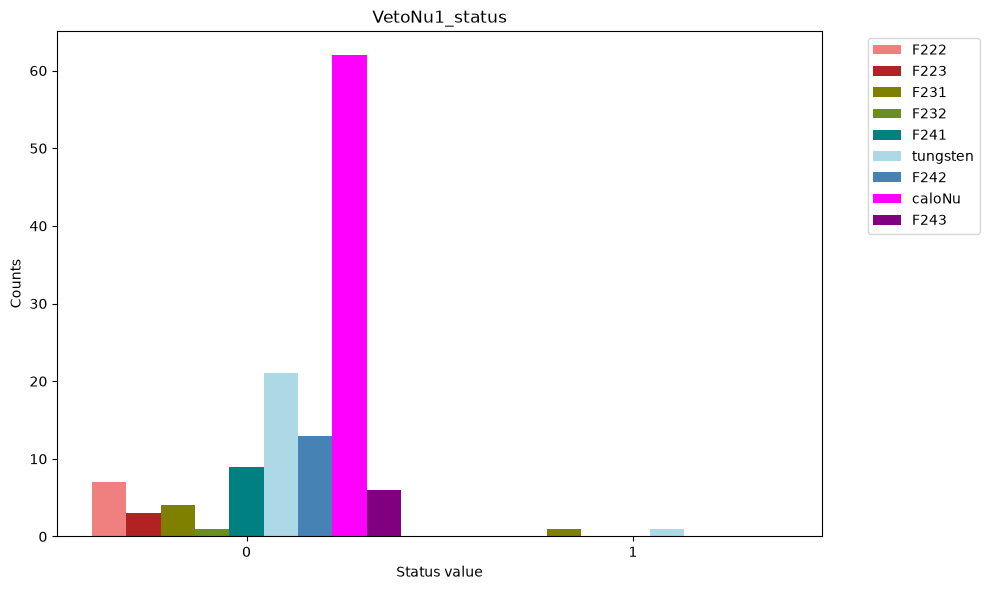

In [97]:
saturation_statuses = [4, 32 + 4, 512 + 4]  # Values indicating saturation

status_hists = [
    "Calo0_status",
    "Calo1_status",
    "Calo2_status",
    "Calo3_status",
    "Preshower0_status",
    "Preshower1_status",
    "Timing0_status",
    "Timing1_status",
    "Timing2_status",
    "Timing3_status",
    "Veto10_status",
    "Veto20_status",
    "Veto21_status",
    "VetoNu0_status",
    "VetoNu1_status",]

import numpy as np
import matplotlib.pyplot as plt

# --- Load all data once, per period, for all status branches together ---
period_data = {}

for period, info in hists_dict.items():
    files = info["files"]
    data = uproot.concatenate([f"{f}:nt" for f in files], library="ak", filter_name=status_hists + ["eventID", "run"])
    period_data[period] = data

# --- Now loop over status variables purely for plotting, no file I/O ---
for h_name in status_hists:

    fig, ax = plt.subplots(figsize=(10, 6))

    values = {}  # period -> {status_value: count}
    periods_to_skip = []

    for period, info in hists_dict.items():

        try:
            status_arr = np.asarray(period_data[period][h_name])
        except Exception as e:
            print(f"Error accessing {h_name} for period {period}: {e}")
            periods_to_skip.append(period)
            continue

        unique, counts = np.unique(status_arr, return_counts=True)
        values[period] = dict(zip(unique, counts))

    all_statuses = sorted(set().union(*[v.keys() for v in values.values()]))

    n_periods = len(hists_dict)
    n_statuses = len(all_statuses)
    bar_width = 0.8 / n_periods

    x = np.arange(n_statuses)

    for i, (period, info) in enumerate(hists_dict.items()):
        if period in periods_to_skip:
            continue
        counts = [values[period].get(status, 0) for status in all_statuses]
        offset = (i - n_periods / 2) * bar_width + bar_width / 2
        ax.bar(x + offset, counts, width=bar_width, label=period, color=info["colour"])

    ax.set_xticks(x)
    ax.set_xticklabels([str(s) for s in all_statuses])
    ax.set_xlabel("Status value")
    ax.set_ylabel("Counts")
    ax.set_title(h_name)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    for s in saturation_statuses:
        try:
            ax.axvline(x=all_statuses.index(s), color='red', linestyle='--', linewidth=1, label=f'Saturation value: {s}')
        except ValueError:
            print(f"Saturation value {s} not found in {h_name} for plotting.")

    plt.tight_layout()
    plt.show()

In [102]:
total_number_of_saturated_entries = 0

all_run_eventIDs = set()  # To track unique (run, eventID) pairs

for period, info in period_data.items():
    for key in info.fields:
        data = info[key]

        # check if any status in data correspond to saturation
        saturated = np.isin(data, saturation_statuses)

        # count the number of saturated entries
        total_number_of_saturated_entries += np.sum(saturated)

        # get eventIDs for saturated entries
        eventIDs = info["eventID"][saturated]

        # Get run numbers for saturated entries
        run_numbers = info["run"][saturated]

        all_run_eventIDs.update(zip(run_numbers, eventIDs))  # Add unique (run, eventID) pairs

        if np.any(saturated):
            print(f"Period: {period}, Status variable: {key}, Saturated entries found: {np.sum(saturated)} {data[saturated]}. Saturated eventIDs: {eventIDs}. Run numbers: {run_numbers}")

print(f"Total number of unique (run, eventID) pairs with saturated entries: {len(all_run_eventIDs)}")

for run, eventID in all_run_eventIDs:
    print(f"Run: {run}, EventID: {eventID}")

Period: F231, Status variable: Veto10_status, Saturated entries found: 2 [4, 36]. Saturated eventIDs: [13029206, 11032028]. Run numbers: [10700, 10792]
Period: F231, Status variable: Veto20_status, Saturated entries found: 2 [4, 4]. Saturated eventIDs: [13029206, 11032028]. Run numbers: [10700, 10792]
Period: F231, Status variable: Veto21_status, Saturated entries found: 2 [4, 4]. Saturated eventIDs: [13029206, 11032028]. Run numbers: [10700, 10792]
Period: tungsten, Status variable: Timing2_status, Saturated entries found: 1 [4]. Saturated eventIDs: [24652897]. Run numbers: [15422]
Period: tungsten, Status variable: Timing3_status, Saturated entries found: 1 [4]. Saturated eventIDs: [24652897]. Run numbers: [15422]
Period: tungsten, Status variable: Veto10_status, Saturated entries found: 1 [4]. Saturated eventIDs: [81812073]. Run numbers: [15445]
Period: tungsten, Status variable: Veto20_status, Saturated entries found: 3 [4, 4, 4]. Saturated eventIDs: [25212567, 24652897, 75314184].

In [94]:
# saturation_statuses = [4, 32 + 4, 512 + 4]  # Values indicating saturation

# status_hists = [
#     "h_Calo0_status",
#     "h_Calo1_status",
#     "h_Calo2_status",
#     "h_Calo3_status",
#     "h_Preshower0_status",
#     "h_Preshower1_status",
#     "h_Timing0_status",
#     "h_Timing1_status",
#     "h_Timing2_status",
#     "h_Timing3_status",
#     "h_Veto10_status",
#     "h_Veto20_status",
#     "h_Veto21_status",
#     "h_VetoNu0_status",
#     "h_VetoNu1_status",]

# for h_name in status_hists:
#     fig, (ax1, ax2) = plt.subplots(
#     1, 2, figsize=(8, 6), sharey=True,
#     gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.05}
#     )

#     hists = []
#     labels = []
#     colours = []
    
#     for period, info in hists_dict.items():
#         try:
#             h_status = deepcopy(info[h_name])
#         except KeyError:
#             continue
#         hists.append(h_status)
#         labels.append(period)
#         colours.append(info["colour"])

#     mplhep.histplot(hists, ax=ax1, label=labels, color=colours, histtype="bar", linewidth=2, flow='show', density=False, stack=True)
#     mplhep.histplot(hists, ax=ax2, label=labels, color=colours, histtype="bar", linewidth=2, flow='show', density=False, stack=True)
    
#     ax1.set_ylabel("Events")
#     ax1.set_xlabel(f"{h_name} value")
#     ax1.legend()

#     ax1.set_xlim(0, 48)
#     ax2.set_xlim(512, 513)
#     ax1.spines['right'].set_visible(False)
#     ax2.spines['left'].set_visible(False)
#     ax2.tick_params(left=False, labelleft=False)
#     d = 0.015
#     kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1)
#     ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
#     ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

#     kwargs.update(transform=ax2.transAxes)
#     ax2.plot((-d, +d), (-d, +d), **kwargs)
#     ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
#     fig.tight_layout()



#     # tick_positions = [0, 1, 2, 4, 16, 32, 36, 48, 512, 513]
#     # tick_positions = [-1, -2, -3, -4, 4, 3, 2, 1]  # Adjusted tick positions for better visibility
#     # tick_labels = ["0", "1", "2", "4", "16", "32", "36", "48", "512", "513"]
#     # tick_labels_dummy = ["" for _ in tick_labels]  # Create a list of empty strings for dummy labels
#     # ax.set_xticks(tick_positions)
#     # ax.set_xticklabels(tick_labels)
#     # ax.set_xticklabels(tick_labels, rotation=45, ha='right')
